<a href="https://colab.research.google.com/github/Thomas-Fabbris/MMIP-polimi/blob/main/Assignments/lecture_7_matching_pursuit_variants.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Notebook Setup
--------------

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy import fft

Set the random number generator seed for ensuring reproducibility of results 
across multiple executions

In [2]:
np.random.seed(42)

Initialize all the variables

In [3]:
M = 32      # signal dimension
N = 2 * M   # number of atoms in the expansion

# Matrix containing the standard basis (a Kronecker delta in each column)
C = np.zeros((M, M))
# Matrix containing the DCT basis (a DCT function in each column)
DCT = np.zeros((M, M))

Generate the 1D-DCT basis and the 1D canonical basis

In [4]:
for i in range(M):
    C[i, i] = 1.0
    DCT[:, i] = fft.idct(C[:, i], norm='ortho')

Define the dictionary $D = [DCT, C]$

Text(0.5, 1.0, 'Our dictionary (M = 32, N = 64)')

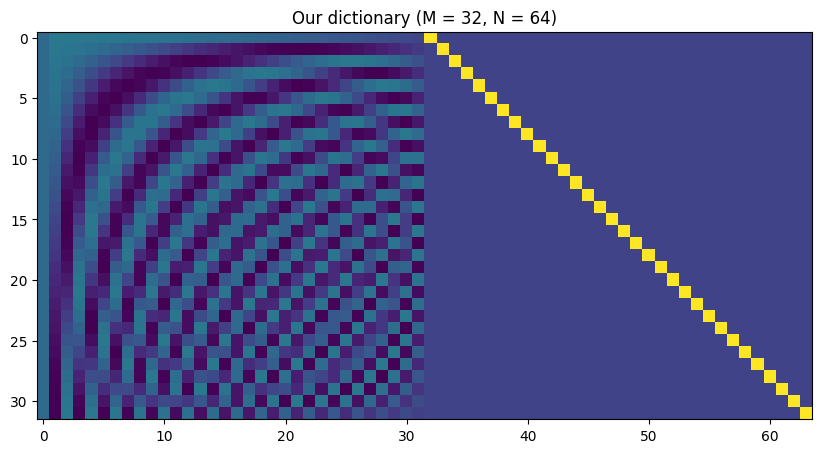

In [5]:
D = np.hstack((DCT, C))

plt.figure(figsize=(10, 10))
plt.imshow(D)
plt.title(f'Our dictionary (M = {M}, N = {N})')

Generate a signal that is sparse w.r.t. $D$
-----------------------------------------
To this purpose add a spike to the sum of few DCT atoms, i.e., add a spike to $\mathbf{s}$ that is sparse w.r.t. $C$  
Bear in mind that the spike is to be considered a signal to be reconstructed, rather than noise

In [6]:
L = 4
sigma_noise = 0.2

Randomly define the coefficients of a sparse representation w.r.t. $DCT$ 

In [7]:
x0 = np.zeros(N)
idxs = np.random.choice(M, L, replace=False)
x0[idxs] = np.random.uniform(-1.0, 1.0, size=(L,))

Choose the spike location

In [8]:
spikeLocation = M + np.random.randint(0, M)
l = np.random.uniform(-5.0, 1.0)
x0[spikeLocation] = l

Synthetize the corresponding signal in the signal domain and add noise


In [9]:
s0 = D @ x0
s = s0 + np.random.normal(0.0, sigma_noise, size=(M,))

Plot the sparse signal

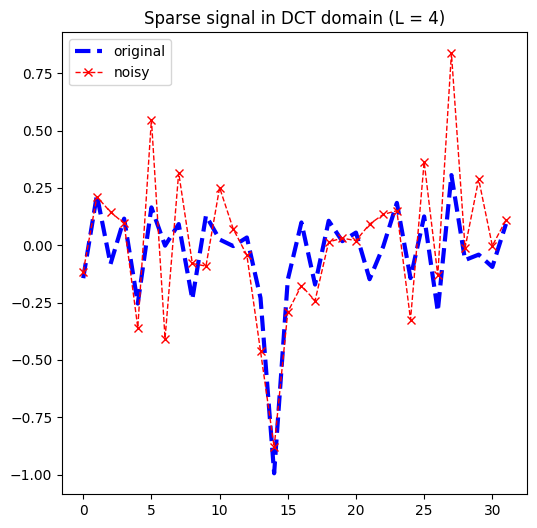

In [10]:
LN_WDT = 2
MRK_SZ = 10

plt.figure(figsize=(6, 6))
plt.plot(s0, 'b--', linewidth=LN_WDT+1)
plt.plot(s, 'r--x', linewidth=LN_WDT-1)
plt.title(f'Sparse signal in DCT domain (L = {L:.0f})')
plt.legend(['original', 'noisy'])

Orthogonal Matching Pursuit
---------------------------

Initialize all the variables, including the residual $r$, namely the components 
of the signal $s$ that cannot be represented by the coefficients   
At the beginning of the execution, $r = s$

In [11]:
x_OMP = np.zeros(N)
r = s                           # Residual vector
omega = []                      # Support set
res_norm = np.linalg.norm(r)
MINIMUM_NORM_RES = 0.1

Continue the execution of OMP until one (or more) of the following conditions 
are met: 
- the sparsity of the representation reaches the sparsity level $L$
- the norm of the residual at the l-th iteration, namely `res_norm`, is below a 
certain minimum value

In [12]:
while np.count_nonzero(x_OMP) < L + 1 and res_norm > MINIMUM_NORM_RES:

    # Sweep step
    e = np.zeros(N)
    for j in range(N):
        e[j] = res_norm ** 2 - (np.dot(r, D[:, j])) ** 2
    jStar = np.argmin(e)
    omega.append(jStar)                 # update the support set

    # Update step
    D_w = D[:, omega]
    x_w = np.linalg.solve(D_w.T @ D_w, D_w.T @ s)
    x_OMP = np.zeros(N)
    x_OMP[omega] = x_w                  # update the solution
    r = s - D_w @ x_w                   # update the residual
    res_norm = np.linalg.norm(r)        # compute residual norm

Reconstruct the signal, by inverting the transformation

In [13]:
s_hat_OMP = D @ x_OMP

Show the results

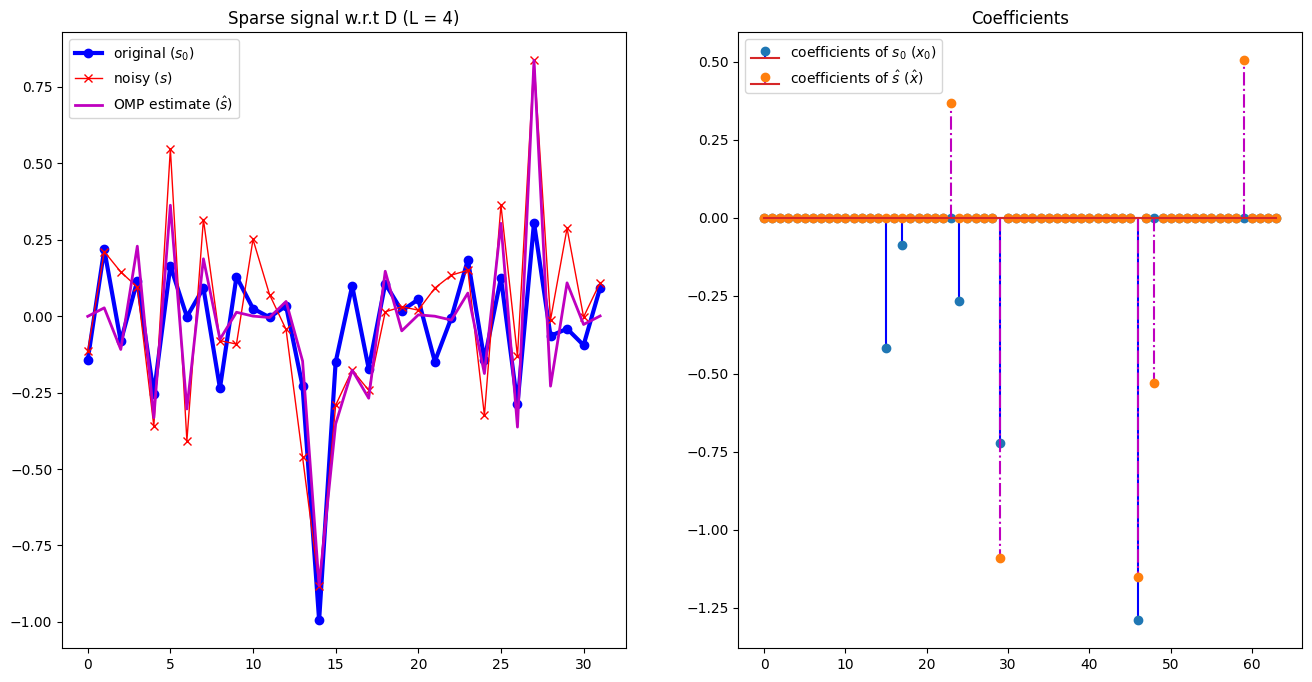

In [14]:
LN_WDT = 2
MRK_SZ = 10

fix, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].plot(s0, 'b-o', linewidth=LN_WDT + 1)
ax[0].plot(s, 'r-x', linewidth=LN_WDT - 1)
ax[0].plot(s_hat_OMP, 'm-', linewidth=LN_WDT)
ax[0].set_title(f'Sparse signal w.r.t D (L = {L:.0f})')
ax[0].legend([
    r'original ($s_0$)',
    r'noisy ($s$)',
    r'OMP estimate ($\hat{s}$)'
])

ax[1].stem(x0, linefmt='b-', markerfmt='C0o')
ax[1].stem(x_OMP, linefmt='m-.', markerfmt='C1o')
ax[1].set_title('Coefficients')
ax[1].legend([
    r'coefficients of $s_0$ ($x_0$)',
    r'coefficients of $\hat{s}$ ($\hat{x}$)'
])

Least Squares Orthogonal Matching Pursuit
-----------------------------------------

Initialize all the variables, including the residual $r$, namely the components 
of the signal $s$ that cannot be represented by the coefficients   
At the beginning of the execution, $r = s$

In [15]:
x_LSOMP = np.zeros(N)
r = s                           # Residual vector
omega = []                      # Support set
res_norm = np.linalg.norm(r)
MINIMUM_NORM_RES = 0.1

Continue the execution of LSOMP until one (or more) of the following conditions 
are met: 
- the sparsity of the representation reaches the sparsity level $L$
- the norm of the residual at the l-th iteration, namely `res_norm`, is below a 
certain minimum value

In [16]:
while np.count_nonzero(x_LSOMP) < L + 1 and res_norm > MINIMUM_NORM_RES:
    # Sweep step
    e = np.full(N, np.inf)

    if len(omega) == 0:
        for j in range(N):
            e[j] = res_norm ** 2 - (np.dot(r, D[:, j])) ** 2
    else:
        for j in range(N):
            if j not in omega:
                D_cand = np.hstack((D[:, omega], D[:, j:j+1]))
                x_cand = np.linalg.lstsq(D_cand, s, rcond=None)[0]
                e[j] = np.linalg.norm(s - D_cand @ x_cand) ** 2

    jStar = np.argmin(e)
    omega.append(jStar)                 # update the support set

    # Update step
    D_w = D[:, omega]
    x_w = np.linalg.lstsq(D_w, s, rcond=None)[0]
    x_LSOMP = np.zeros(N)
    x_LSOMP[omega] = x_w                # update the solution
    r = s - D_w @ x_w                   # update the residual
    res_norm = np.linalg.norm(r)        # compute residual norm

Reconstruct the signal, by inverting the transformation

In [17]:
s_hat_LSOMP = D @ x_LSOMP

Show the results

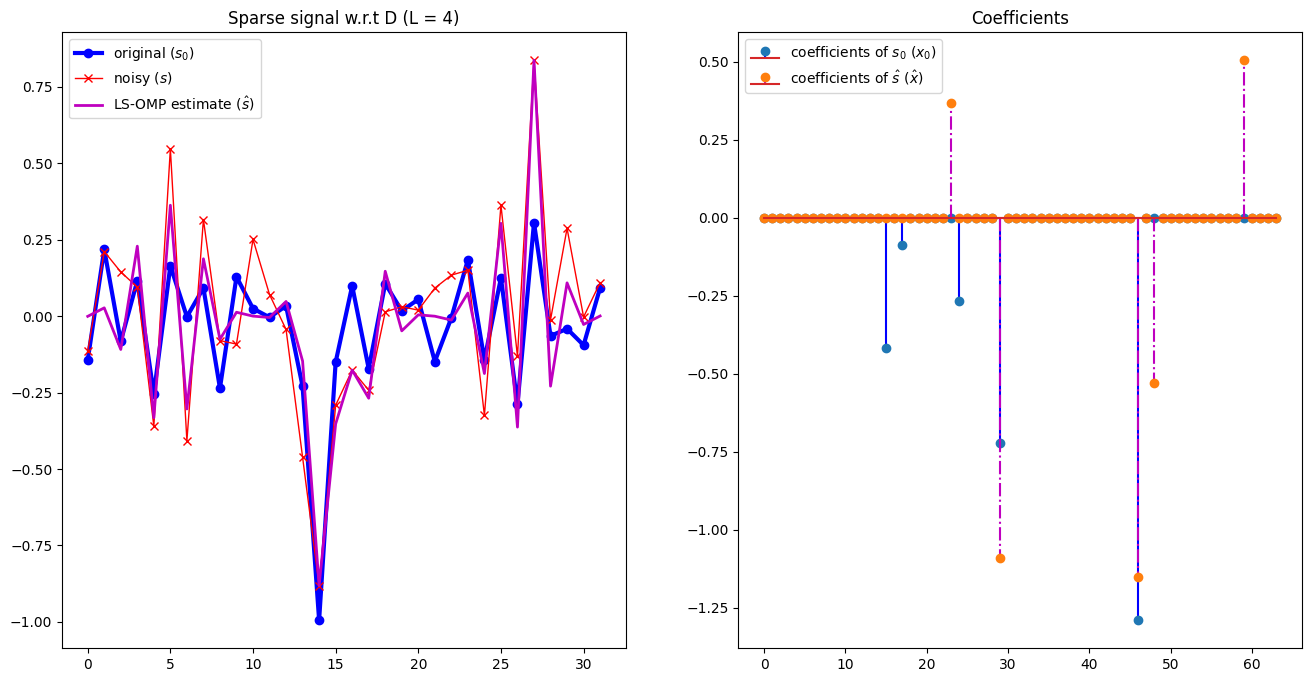

In [18]:
LN_WDT = 2
MRK_SZ = 10

fix, ax = plt.subplots(1, 2, figsize=(16, 8))
ax[0].plot(s0, 'b-o', linewidth=LN_WDT + 1)
ax[0].plot(s, 'r-x', linewidth=LN_WDT - 1)
ax[0].plot(s_hat_LSOMP, 'm-', linewidth=LN_WDT)
ax[0].set_title(f'Sparse signal w.r.t D (L = {L:.0f})')
ax[0].legend([
    r'original ($s_0$)',
    r'noisy ($s$)',
    r'LS-OMP estimate ($\hat{s}$)'
])

ax[1].stem(x0, linefmt='b-', markerfmt='C0o')
ax[1].stem(x_LSOMP, linefmt='m-.', markerfmt='C1o')
ax[1].set_title('Coefficients')
ax[1].legend([
    r'coefficients of $s_0$ ($x_0$)',
    r'coefficients of $\hat{s}$ ($\hat{x}$)'
])

For convenience, we have extracted and refactored the code for OMP and LS-OMP algorithms into 
two distinct Python functions, named `omp` and `ls_omp` respectively

Utility function for input validation of Matching Pursuit algorithms

In [ ]:
def _validate_omp_inputs(D, s, L, min_res_norm):
    if not isinstance(D, np.ndarray) or not isinstance(s, np.ndarray):
        raise TypeError("D and s must be numpy arrays!")
    if D.ndim != 2 or s.ndim != 1:
        raise ValueError(
            f"Expected D to be 2D and s to be 1D, got {D.ndim}D and {s.ndim}D.")
    if D.shape[0] != s.shape[0]:
        raise ValueError(
            f"Dimension mismatch: D rows ({D.shape[0]}) != s length ({s.shape[0]}).")
    if not isinstance(L, int) or L <= 0:
        raise ValueError("The sparsity level L must be a positive integer!")
    if min_res_norm < 0:
        raise ValueError("min_res_norm must be positive!")

In [ ]:
def omp(D, s, L, min_res_norm=0.1):
    """
    Orthogonal Matching Pursuit (OMP) algorithm.

    Finds a sparse representation of a signal `s` with respect to a redundant 
    dictionary `D`.

    Parameters
    ----------
    D : numpy.ndarray
        A 2D array of shape (M, N) representing the redundant dictionary matrix.
    s : numpy.ndarray
        A 1D array of shape (M,) representing the signal vector.
    L : int
        The maximum allowed sparsity (number of non-zero coefficients).
    min_res_norm : float, optional
        The stopping threshold for the residual norm (default is 0.1).

    Returns
    -------
    x : numpy.ndarray
        A 1D array of shape (N,) containing the computed sparse code.
    res_norm : float
        The norm of the final residual vector.

    Raises
    ------
    RuntimeError
        If a linear algebra error occurs during the update step.
    """
    _validate_omp_inputs(D, s, L, min_res_norm)

    M, N = D.shape
    x = np.zeros(N)
    r = s.copy()                    # Residual vector
    omega = []                      # Support set
    res_norm = np.linalg.norm(r)

    while np.count_nonzero(x) < L and res_norm > min_res_norm:
        # Sweep step
        e = np.zeros(N)
        for j in range(N):
            e[j] = res_norm ** 2 - (np.dot(r, D[:, j])) ** 2

        j_star = int(np.argmin(e))

        omega.append(j_star)                 # update the support set

        # Update step
        D_w = D[:, omega]

        try:
            x_w = np.linalg.solve(D_w.T @ D_w, D_w.T @ s)
        except np.linalg.LinAlgError as ex:
            raise RuntimeError(
                "Linear algebra error during update step. The matrix D_w.T @ D_w might be singular.") from ex

        x = np.zeros(N)
        x[omega] = x_w                      # update the solution
        r = s - D_w @ x_w                   # update the residual
        res_norm = np.linalg.norm(r)        # compute residual norm

    return x, res_norm

Utility function called in the implementation of `ls_omp` function

In [ ]:
def _ls_omp_sweep(D, s, r, omega, res_norm):
    N = D.shape[1]
    e = np.full(N, np.inf)

    if len(omega) == 0:
        for j in range(N):
            e[j] = res_norm ** 2 - (np.dot(r, D[:, j])) ** 2
        return int(np.argmin(e))

    for j in range(N):
        if j not in omega:
            D_cand = np.hstack((D[:, omega], D[:, j:j+1]))
            x_cand = np.linalg.lstsq(D_cand, s, rcond=None)[0]
            e[j] = np.linalg.norm(s - D_cand @ x_cand) ** 2

    return int(np.argmin(e))

In [ ]:
def ls_omp(D, s, L, min_res_norm=0.1):
    """
    Least Squares Orthogonal Matching Pursuit (LS-OMP) algorithm.

    Finds a sparse representation of a signal `s` with respect to a redundant 
    dictionary `D`.

    Parameters
    ----------
    D : numpy.ndarray
        A 2D array of shape (M, N) representing the redundant dictionary matrix.
    s : numpy.ndarray
        A 1D array of shape (M,) representing the signal vector.
    L : int
        The sparsity level.
    min_res_norm : float, optional
        The stopping threshold for the residual norm (default is 0.1).

    Returns
    -------
    x : numpy.ndarray
        A 1D array of shape (N,) containing the computed sparse code.
    res_norm : float
        The norm of the final residual vector.

    Raises
    ------
    RuntimeError
        If the least-squares solver fails.
    """
    _validate_omp_inputs(D, s, L, min_res_norm)

    M, N = D.shape
    x = np.zeros(N)
    r = s.copy()                    # Residual vector
    omega = []                      # Support set
    res_norm = np.linalg.norm(r)

    while np.count_nonzero(x) < L and res_norm > min_res_norm:

        j_star = _ls_omp_sweep(D, s, r, omega, res_norm)

        if j_star in omega:
            raise RuntimeError(
                f"Algorithm stalled: atom index {j_star} was selected multiple times.")

        omega.append(j_star)                 # update the support set

        # Update step
        D_w = D[:, omega]

        try:
            x_w = np.linalg.lstsq(D_w, s, rcond=None)[0]
        except np.linalg.LinAlgError as exc:
            raise RuntimeError(
                "Linear algebra error during update step. The least squares solver failed.") from exc

        x = np.zeros(N)
        x[omega] = x_w                      # update the solution
        r = s - D_w @ x_w                   # update the residual
        res_norm = np.linalg.norm(r)        # compute residual norm

    return x, res_norm